In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


In [ ]:
from pathlib import Path

def _find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "dataset").exists():
            return p
    return cwd

ROOT = _find_project_root()
df_energy_path = ROOT / "dataset" / "Cleaned" / "cleaned_sorted_energy_dataset.xlsx"
df_energy = pd.read_excel(df_energy_path)

df_energy.columns = df_energy.columns.str.strip()
df_energy["Date"] = pd.to_datetime(df_energy["Date"])

df_energy.head()

,Home ID,Appliance Type,Energy Consumption (kWh),Hour,Date,Outdoor Temperature (C),Season,Household Size,Month
0,5,Air Conditioning,2.0,8,2023-01-24,-7.2,Winter,4,1
1,325,Air Conditioning,2.0,15,2023-02-11,26.4,Winter,4,2
2,367,Air Conditioning,2.0,5,2023-02-16,6.3,Winter,2,2
3,475,Air Conditioning,2.0,22,2023-02-24,4.0,Winter,4,2
4,34,Air Conditioning,2.0,3,2023-03-02,3.4,Winter,2,3


In [40]:
appliance = "Air Conditioning"

# Build per-home time-ordered data for this appliance
_df_app = df_energy[df_energy['Appliance Type'] == appliance].copy()

_df_app['Date'] = pd.to_datetime(_df_app['Date'])
_df_app['Timestamp'] = _df_app['Date'] + pd.to_timedelta(_df_app['Hour'], unit='h')
_df_app = _df_app.sort_values(['Home ID', 'Timestamp'])

_df_app['hour'] = _df_app['Timestamp'].dt.hour
_df_app['day'] = _df_app['Timestamp'].dt.day
_df_app['weekday'] = _df_app['Timestamp'].dt.weekday
_df_app['month'] = _df_app['Timestamp'].dt.month

df_a = _df_app
print(f"Appliance: {appliance} | rows: {len(df_a)} | homes: {df_a['Home ID'].nunique()}")


Appliance: Air Conditioning | rows: 10067 | homes: 500


In [41]:
target_col = 'Energy Consumption (kWh)'
exog_cols = ['hour', 'day', 'weekday', 'month', 'Outdoor Temperature (C)', 'Household Size']

# NOTE: sequences are built per-home in the next cell; no single global arrays here.


In [42]:
# Build sequences within each home (no mixed-home windows), then combine.
# This version uses the TOP_N homes (by record count) so the dataset isn't too sparse.
# It also adds a delta-time feature to handle irregular sampling.

TIME_STEPS = 8
TOP_N_HOMES = 50

# pick the most-populated homes for this appliance
home_counts = df_a['Home ID'].value_counts().head(TOP_N_HOMES)
top_homes = set(home_counts.index.astype(int).tolist())
df_top = df_a[df_a['Home ID'].isin(top_homes)].copy()

print(f"Top homes selected: {len(top_homes)}")
print(f"Rows used: {len(df_top)}")

# helper: build raw matrix for one home

def build_home_raw(df_h: pd.DataFrame) -> np.ndarray:
    df_h = df_h.sort_values('Timestamp').copy()

    # delta time in hours between observations
    delta_hours = df_h['Timestamp'].diff().dt.total_seconds().div(3600.0).fillna(0.0)
    # cap extreme gaps to reduce scale issues
    delta_hours = delta_hours.clip(lower=0.0, upper=48.0)

    feats = df_h[exog_cols].copy()
    feats['delta_hours'] = delta_hours.to_numpy()

    raw_h = np.concatenate(
        [df_h[[target_col]].to_numpy(), feats.to_numpy()],
        axis=1,
    )
    return raw_h

# build per-home raw arrays + per-home time split
raw_by_home: dict[int, tuple[np.ndarray, int]] = {}
train_rows = []

for hid, df_h in df_top.groupby('Home ID'):
    raw_h = build_home_raw(df_h)
    if len(raw_h) < (TIME_STEPS + 10):
        continue

    split_time = int(0.8 * len(raw_h))
    if split_time <= TIME_STEPS or (len(raw_h) - split_time) <= 5:
        continue

    hid_int = int(hid)
    raw_by_home[hid_int] = (raw_h, split_time)
    train_rows.append(raw_h[:split_time])

if not train_rows:
    raise ValueError("Not enough per-home data to build sequences. Try increasing TOP_N_HOMES or lowering TIME_STEPS.")

train_concat = np.vstack(train_rows)

# Fit scalers on training rows only (prevents leakage)
scaler_y = MinMaxScaler()
scaler_X = MinMaxScaler()
scaler_y.fit(train_concat[:, 0:1])
scaler_X.fit(train_concat[:, 1:])

def scale_raw(raw: np.ndarray) -> np.ndarray:
    return np.concatenate(
        [scaler_y.transform(raw[:, 0:1]), scaler_X.transform(raw[:, 1:])],
        axis=1,
    )

def create_sequences(data: np.ndarray, time_steps: int = 24, target_col_index: int = 0):
    Xs, ys = [], []
    for i in range(time_steps, len(data)):
        Xs.append(data[i - time_steps : i, :])
        ys.append(data[i, target_col_index])
    return np.array(Xs), np.array(ys)

X_train_list, y_train_list, X_test_list, y_test_list = [], [], [], []

for hid, (raw_h, split_time) in raw_by_home.items():
    scaled_h = scale_raw(raw_h)

    train_scaled_h = scaled_h[:split_time]
    test_scaled_h = scaled_h[split_time - TIME_STEPS:]

    X_h_tr, y_h_tr = create_sequences(train_scaled_h, TIME_STEPS, target_col_index=0)
    X_h_te, y_h_te = create_sequences(test_scaled_h, TIME_STEPS, target_col_index=0)

    if len(X_h_tr) > 0:
        X_train_list.append(X_h_tr)
        y_train_list.append(y_h_tr)
    if len(X_h_te) > 0:
        X_test_list.append(X_h_te)
        y_test_list.append(y_h_te)

X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)
X_test = np.concatenate(X_test_list, axis=0)
y_test = np.concatenate(y_test_list, axis=0)

print("Homes used:", len(raw_by_home))
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)


Top homes selected: 50
Rows used: 1426
Homes used: 50
X_train: (718, 8, 8) y_train: (718,)
X_test: (308, 8, 8) y_test: (308,)


In [ ]:
# Sequence creation happens per-home in the previous cell.
# This cell is kept for readability.
pass


X_train: (4, 24, 7) y_train: (4,)
X_test: (7, 24, 7) y_test: (7,)


In [24]:
# Train/test are already split by time above.
# This cell is kept as a no-op for notebook flow.
pass


In [43]:
# X_train/X_test are 3D: (samples, time_steps, features)
# Features = 1 target-history + exog + delta_hours (scaled)
X_train.shape, X_test.shape

((718, 8, 8), (308, 8, 8))

In [44]:
n_features = X_train.shape[2]

lstm_model = Sequential()
lstm_model.add(Input(shape=(TIME_STEPS, n_features)))

lstm_model.add(LSTM(64, return_sequences=True))
lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(32))
lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

lstm_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 8, 64)          │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,137 (121.63 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
)

history = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 0.1390 - val_loss: 0.1106
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0866 - val_loss: 0.0973
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0827 - val_loss: 0.0981
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0833 - val_loss: 0.1048
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0851 - val_loss: 0.0992
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0840 - val_loss: 0.0975
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0815 - val_loss: 0.0964
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0820 - val_loss: 0.0968
Epoch 9/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0831 - val_loss: 0.0970
Epoch 10/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0804 - val_loss: 0.0964
Epoch 11/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0819 - val_loss: 0.0978
Epoch 12/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0

In [ ]:
from pathlib import Path

# Save the trained LSTM model next to this project

def _find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "dataset").exists():
            return p
    return cwd

ROOT = _find_project_root()
models_dir = ROOT / "models"
models_dir.mkdir(parents=True, exist_ok=True)

safe_appliance = appliance.replace(" ", "_")
model_path = models_dir / f"lstm_{safe_appliance}_allhomes.h5"

lstm_model.save(model_path)
print(f"Saved model to: {model_path}")

from tensorflow.keras.models import load_model

# Quick load test (ensures the saved file is usable)
loaded_model = load_model(model_path)
_ = loaded_model.predict(X_test[:1], verbose=0)
print("Loaded model OK")


Saved model to: C:\Users\user\internship 1 month\infosys internsip\lstm_energy_model.h5
Loaded model OK


In [46]:
y_pred_scaled = lstm_model.predict(X_test)

y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = scaler_y.inverse_transform(y_pred_scaled)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step


In [47]:
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("Updated LSTM MAE:", mae)
print("Updated LSTM RMSE:", rmse)

Updated LSTM MAE: 0.7687030489723404
Updated LSTM RMSE: 0.8877390127468077


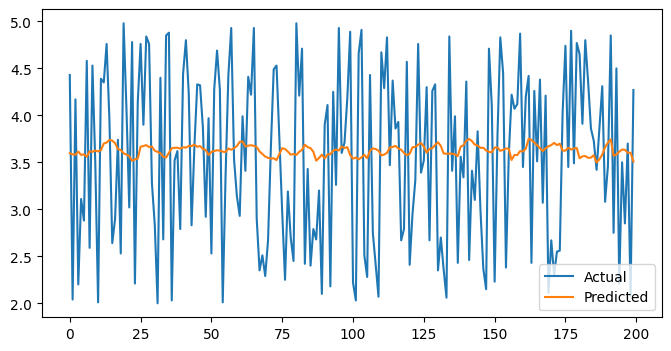

In [49]:
plt.figure(figsize=(8,4))
plt.plot(y_test_actual[:200], label="Actual")
plt.plot(y_pred_actual[:200], label="Predicted")
plt.legend()
plt.show()

In [48]:
print(np.std(y_pred_actual))
print(np.std(y_test_actual))

0.05747593
0.8830636037212933


In [16]:
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.7466102313758011
RMSE: 0.867046935748646


In [ ]:
# --- Train LSTM for ALL appliances using per-home sequences (for dashboard) ---
# Uses TOP_N homes per appliance and adds delta-time feature.
# Note: can take several minutes.

from pathlib import Path

def _find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'dataset').exists():
            return p
    return cwd

ROOT = _find_project_root()
models_dir = ROOT / 'models'
outputs_dir = ROOT / 'outputs'
models_dir.mkdir(parents=True, exist_ok=True)
outputs_dir.mkdir(parents=True, exist_ok=True)

TIME_STEPS = 8
TOP_N_HOMES = 50
EPOCHS = 10
BATCH_SIZE = 64

appliances_to_train = sorted(df_energy['Appliance Type'].unique().tolist())

target_col = 'Energy Consumption (kWh)'
base_exog_cols = ['Outdoor Temperature (C)', 'Household Size']

rows = []

def create_sequences(data: np.ndarray, time_steps: int = 24, target_col_index: int = 0):
    Xs, ys = [], []
    for i in range(time_steps, len(data)):
        Xs.append(data[i - time_steps:i, :])
        ys.append(data[i, target_col_index])
    return np.array(Xs), np.array(ys)

for app in appliances_to_train:
    df_app = df_energy[df_energy['Appliance Type'] == app].copy()
    if df_app.empty:
        continue

    df_app['Date'] = pd.to_datetime(df_app['Date'])
    df_app['Timestamp'] = df_app['Date'] + pd.to_timedelta(df_app['Hour'], unit='h')
    df_app = df_app.sort_values(['Home ID', 'Timestamp'])

    df_app['hour'] = df_app['Timestamp'].dt.hour
    df_app['day'] = df_app['Timestamp'].dt.day
    df_app['weekday'] = df_app['Timestamp'].dt.weekday
    df_app['month'] = df_app['Timestamp'].dt.month

    exog_cols = ['hour', 'day', 'weekday', 'month', *base_exog_cols]

    if any(c not in df_app.columns for c in [target_col, *exog_cols]):
        continue

    # pick top homes for this appliance
    home_counts = df_app['Home ID'].value_counts().head(TOP_N_HOMES)
    top_homes = set(home_counts.index.astype(int).tolist())
    df_top = df_app[df_app['Home ID'].isin(top_homes)].copy()

    def build_home_raw(df_h: pd.DataFrame) -> np.ndarray:
        df_h = df_h.sort_values('Timestamp').copy()
        delta_hours = df_h['Timestamp'].diff().dt.total_seconds().div(3600.0).fillna(0.0)
        delta_hours = delta_hours.clip(lower=0.0, upper=48.0)

        feats = df_h[exog_cols].copy()
        feats['delta_hours'] = delta_hours.to_numpy()

        raw_h = np.concatenate([df_h[[target_col]].to_numpy(), feats.to_numpy()], axis=1)
        return raw_h

    raw_by_home = {}
    train_rows = []

    for hid, df_h in df_top.groupby('Home ID'):
        raw_h = build_home_raw(df_h)
        if len(raw_h) < (TIME_STEPS + 10):
            continue

        split_time = int(0.8 * len(raw_h))
        if split_time <= TIME_STEPS or (len(raw_h) - split_time) <= 5:
            continue

        raw_by_home[int(hid)] = (raw_h, split_time)
        train_rows.append(raw_h[:split_time])

    if len(train_rows) < 5:
        continue

    train_concat = np.vstack(train_rows)
    scaler_y_local = MinMaxScaler()
    scaler_X_local = MinMaxScaler()
    scaler_y_local.fit(train_concat[:, 0:1])
    scaler_X_local.fit(train_concat[:, 1:])

    def scale_raw(raw: np.ndarray) -> np.ndarray:
        return np.concatenate(
            [scaler_y_local.transform(raw[:, 0:1]), scaler_X_local.transform(raw[:, 1:])],
            axis=1,
        )

    X_train_list, y_train_list, X_test_list, y_test_list = [], [], [], []

    for hid, (raw_h, split_time) in raw_by_home.items():
        scaled_h = scale_raw(raw_h)
        train_scaled_h = scaled_h[:split_time]
        test_scaled_h = scaled_h[split_time - TIME_STEPS:]

        X_h_tr, y_h_tr = create_sequences(train_scaled_h, TIME_STEPS, 0)
        X_h_te, y_h_te = create_sequences(test_scaled_h, TIME_STEPS, 0)

        if len(X_h_tr) > 0:
            X_train_list.append(X_h_tr)
            y_train_list.append(y_h_tr)
        if len(X_h_te) > 0:
            X_test_list.append(X_h_te)
            y_test_list.append(y_h_te)

    X_train_app = np.concatenate(X_train_list, axis=0)
    y_train_app = np.concatenate(y_train_list, axis=0)
    X_test_app = np.concatenate(X_test_list, axis=0)
    y_test_app = np.concatenate(y_test_list, axis=0)

    if len(X_train_app) < 500 or len(X_test_app) < 100:
        continue

    n_features = X_train_app.shape[2]

    model_app = Sequential([
        Input(shape=(TIME_STEPS, n_features)),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1),
    ])
    model_app.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    model_app.fit(
        X_train_app,
        y_train_app,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0,
    )

    y_pred_scaled_app = model_app.predict(X_test_app, verbose=0)
    y_test_actual_app = scaler_y_local.inverse_transform(y_test_app.reshape(-1, 1))
    y_pred_actual_app = scaler_y_local.inverse_transform(y_pred_scaled_app)

    mae_app = float(mean_absolute_error(y_test_actual_app, y_pred_actual_app))
    rmse_app = float(np.sqrt(mean_squared_error(y_test_actual_app, y_pred_actual_app)))

    safe_app = app.replace(' ', '_')
    model_file = models_dir / f"lstm_{safe_app}_top{TOP_N_HOMES}_ts{TIME_STEPS}.h5"
    model_app.save(model_file)

    rows.append({
        'appliance': app,
        'homes_used': int(len(raw_by_home)),
        'mae': mae_app,
        'rmse': rmse_app,
        'train_samples': int(len(X_train_app)),
        'test_samples': int(len(X_test_app)),
        'model_path': model_file.relative_to(ROOT).as_posix(),
    })

metrics_df = pd.DataFrame(rows).sort_values(['rmse', 'mae'])
metrics_path = outputs_dir / 'lstm_metrics_per_appliance.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f"Saved metrics: {metrics_path}")
metrics_df

Saved metrics: C:\Users\user\internship 1 month\infosys internsip\outputs\lstm_metrics_per_appliance.csv


,appliance,homes_used,mae,rmse,train_samples,test_samples,model_path
3,Fridge,50,0.095004,0.111355,694,306,C:\Users\user\internship 1 month\infosys inter...
5,Lights,50,0.425261,0.501565,726,308,C:\Users\user\internship 1 month\infosys inter...
1,Computer,50,0.430523,0.505189,689,305,C:\Users\user\internship 1 month\infosys inter...
6,Microwave,50,0.458106,0.522974,706,304,C:\Users\user\internship 1 month\infosys inter...
2,Dishwasher,50,0.461918,0.526598,686,302,C:\Users\user\internship 1 month\infosys inter...
9,Washing Machine,50,0.464062,0.539003,707,312,C:\Users\user\internship 1 month\infosys inter...
7,Oven,50,0.477460,0.541841,698,303,C:\Users\user\internship 1 month\infosys inter...
8,TV,50,0.455076,0.543258,706,308,C:\Users\user\internship 1 month\infosys inter...
4,Heater,49,0.764311,0.887068,684,301,C:\Users\user\internship 1 month\infosys inter...
0,Air Conditioning,50,0.768999,0.890356,718,308,C:\Users\user\internship 1 month\infosys inter...


In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
from pathlib import Path

results = {}

def _find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / 'dataset').exists():
            return p
    return cwd

ROOT = _find_project_root()
df_energy_path = ROOT / 'dataset' / 'Cleaned' / 'cleaned_sorted_energy_dataset.xlsx'
df_energy = pd.read_excel(df_energy_path)
df_energy.columns = df_energy.columns.str.strip()
df_energy['Date'] = pd.to_datetime(df_energy['Date'])

# Ensure time order for lag/rolling features
df_energy = df_energy.sort_values(['Appliance Type', 'Date', 'Hour'])
df_energy['hour'] = df_energy['Hour']
df_energy['day'] = df_energy['Date'].dt.day
df_energy['weekday'] = df_energy['Date'].dt.weekday
df_energy['month'] = df_energy['Month']
df_energy['lag_1'] = df_energy.groupby('Appliance Type')['Energy Consumption (kWh)'].shift(1)
df_energy['lag_24'] = df_energy.groupby('Appliance Type')['Energy Consumption (kWh)'].shift(24)
df_energy['rolling_mean_24'] = (
    df_energy.groupby('Appliance Type')['Energy Consumption (kWh)']
    .transform(lambda x: x.rolling(24).mean().shift(1))
)
df_energy = df_energy.dropna()

appliances = df_energy['Appliance Type'].unique()

for appliance in appliances:
    
    df_a = df_energy[df_energy['Appliance Type'] == appliance]
    
    features = [
        'hour','day','weekday','month',
        'Outdoor Temperature (C)','Household Size',
        'lag_1','lag_24','rolling_mean_24'
    ]
    
    X = df_a[features]
    y = df_a['Energy Consumption (kWh)']
    
    split = int(len(X) * 0.8)
    
    X_train = X.iloc[:split]
    X_test = X.iloc[split:]
    
    y_train = y.iloc[:split]
    y_test = y.iloc[split:]
    
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results[appliance] = {
        "MAE": mae,
        "RMSE": rmse
    }

# Show results
for appliance, metrics in results.items():
    print(f"{appliance}")
    print("MAE:", metrics["MAE"])
    print("RMSE:", metrics["RMSE"])
    print("-------------------")

Air Conditioning
MAE: 0.7382781981085117
RMSE: 0.8717488250377535
-------------------
Computer
MAE: 0.4451202368951613
RMSE: 0.5175236431857972
-------------------
Dishwasher
MAE: 0.45123099255583127
RMSE: 0.5250522286403974
-------------------
Fridge
MAE: 0.09983569626639757
RMSE: 0.1163756204020657
-------------------
Heater
MAE: 0.7558187343671837
RMSE: 0.8805789579230352
-------------------
Lights
MAE: 0.4455877946954814
RMSE: 0.5201601267701913
-------------------
Microwave
MAE: 0.44696254408060454
RMSE: 0.5191361595476413
-------------------
Oven
MAE: 0.44723761976802817
RMSE: 0.5228939150288331
-------------------
TV
MAE: 0.4468266818411735
RMSE: 0.5194248746142043
-------------------
Washing Machine
MAE: 0.4490636203423968
RMSE: 0.522414721061459
-------------------
